In [2]:
import json
import matplotlib.pyplot as plt

import os
os.chdir("/home/patrick/ansermodelling")

In [4]:
def load_jsonl(path):
    records = []
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

records = load_jsonl('models/train_log.json')

In [6]:
epochs = [r['epoch'] for r in records]
train_loss = [r['train_loss'] for r in records]
val_loss = [r['test_loss'] for r in records]
ep_mean = [r['e_p_mean'] for r in records]
en_mean = [r['e_n_mean'] for r in records]

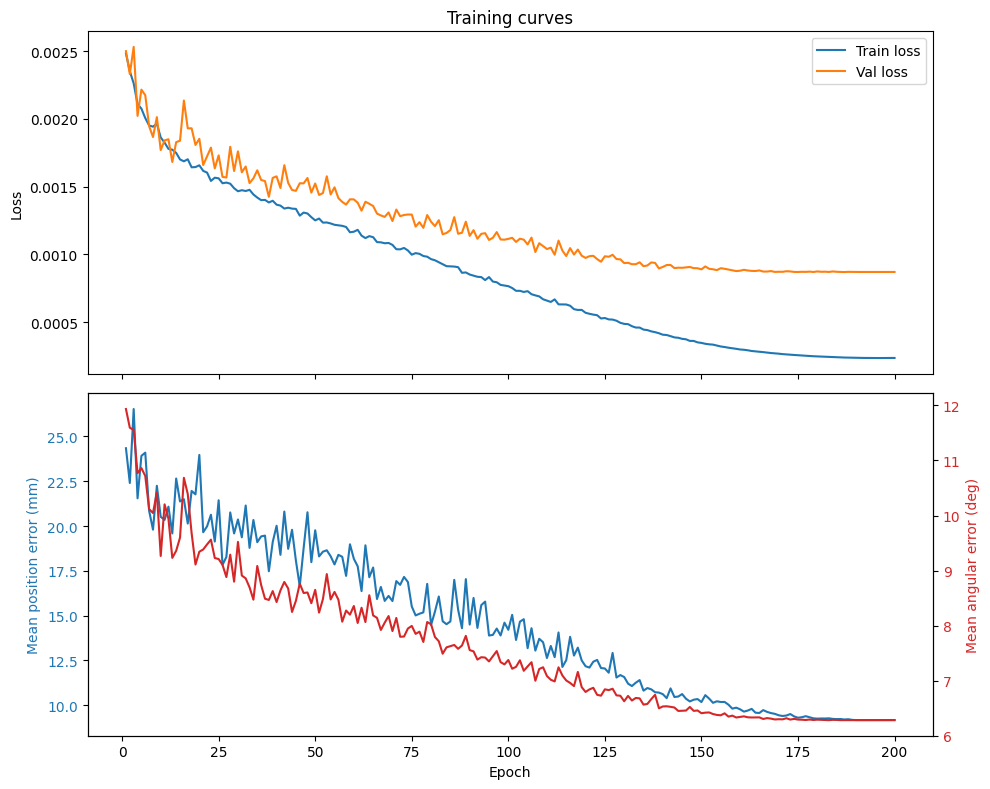

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)


ax1.plot(epochs, train_loss, label='Train loss')
ax1.plot(epochs, val_loss, label='Val loss')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.set_title('Training curves')


ax2.plot(epochs, ep_mean, color='tab:blue', label='Position error (mm)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Mean position error (mm)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

ax2b = ax2.twinx()
ax2b.plot(epochs, en_mean, color='tab:red', label='Angular error (deg)')
ax2b.set_ylabel('Mean angular error (deg)', color='tab:red')
ax2b.tick_params(axis='y', labelcolor='tab:red')

plt.tight_layout()
plt.savefig('report/figs/training_curves.png')
plt.show()